# 🌾 Rice Grain Segmentation — SAM v2 (Improved)

### Fixes over v1
| Issue in v1 | Fix in v2 |
|---|---|
| Large background blob colored (top-right green) | Tighter `MAX_AREA_FRACTION` + **shape filter** (aspect ratio + solidity) rejects non-grain regions |
| Jagged / harsh grain boundaries | **Mask smoothing**: morphological closing → Gaussian blur → re-threshold |
| Used ViT-B (lighter model) | **ViT-H** by default (best accuracy); auto-falls back to ViT-L if VRAM < 16 GB |
| No background foreground pre-separation | **CLAHE pre-processing** boosts grain-background contrast before SAM |

### Runtime recommendation
- **Colab Free (T4, 15 GB VRAM)**: use `vit_l` — ViT-H may OOM on large images
- **Colab Pro / Pro+ (A100, 40 GB VRAM)**: use `vit_h` ← notebook default
- The notebook auto-detects VRAM and downgrades if needed.

## Step 1 — Install Dependencies

In [1]:
!pip install git+https://github.com/facebookresearch/segment-anything.git -q
!pip install opencv-python-headless matplotlib numpy Pillow scipy -q

import torch
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU      : {torch.cuda.get_device_name(0)}  ({vram_gb:.1f} GB VRAM)")

  Preparing metadata (setup.py) ... done
PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : Tesla T4  (15.6 GB VRAM)


## Step 2 — Auto-Select & Download Checkpoint

- **≥ 16 GB VRAM** → ViT-H (~2.4 GB) — best quality
- **< 16 GB VRAM** → ViT-L (~1.2 GB) — still excellent
- Override by setting `FORCE_MODEL_TYPE` below.

In [2]:
import os

FORCE_MODEL_TYPE = None  # set to "vit_b" / "vit_l" / "vit_h" to override auto-select

CHECKPOINT_URLS = {
    "vit_b": "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth",
    "vit_l": "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_l_0b3195.pth",
    "vit_h": "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth",
}

if FORCE_MODEL_TYPE:
    MODEL_TYPE = FORCE_MODEL_TYPE
elif torch.cuda.is_available():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    MODEL_TYPE = "vit_h" if vram_gb >= 16 else "vit_l"
else:
    MODEL_TYPE = "vit_b"   # CPU fallback

CHECKPOINT_PATH = f"sam_{MODEL_TYPE}.pth"
print(f"Selected model: {MODEL_TYPE.upper()}  →  {CHECKPOINT_PATH}")

if not os.path.exists(CHECKPOINT_PATH):
    url = CHECKPOINT_URLS[MODEL_TYPE]
    print(f"Downloading from {url} ...")
    !wget -q --show-progress "{url}" -O "{CHECKPOINT_PATH}"
    print("Download complete.")
else:
    print("Checkpoint already cached.")

Selected model: VIT_L  →  sam_vit_l.pth
sam_vit_l.pth       100%[===================>]   1.16G   174MB/s    in 6.6s    
Download complete.


## Step 3 — Upload & Pre-process Input Image

**CLAHE** (Contrast Limited Adaptive Histogram Equalization) is applied to the luminance channel to boost grain-boundary contrast before SAM sees the image. This helps separate grains from the dark background more reliably.

Upload your rice grain image (JPG or PNG):


Saving InputImage.jpg to InputImage.jpg
Loaded: InputImage.jpg
Image shape: 847 x 1024


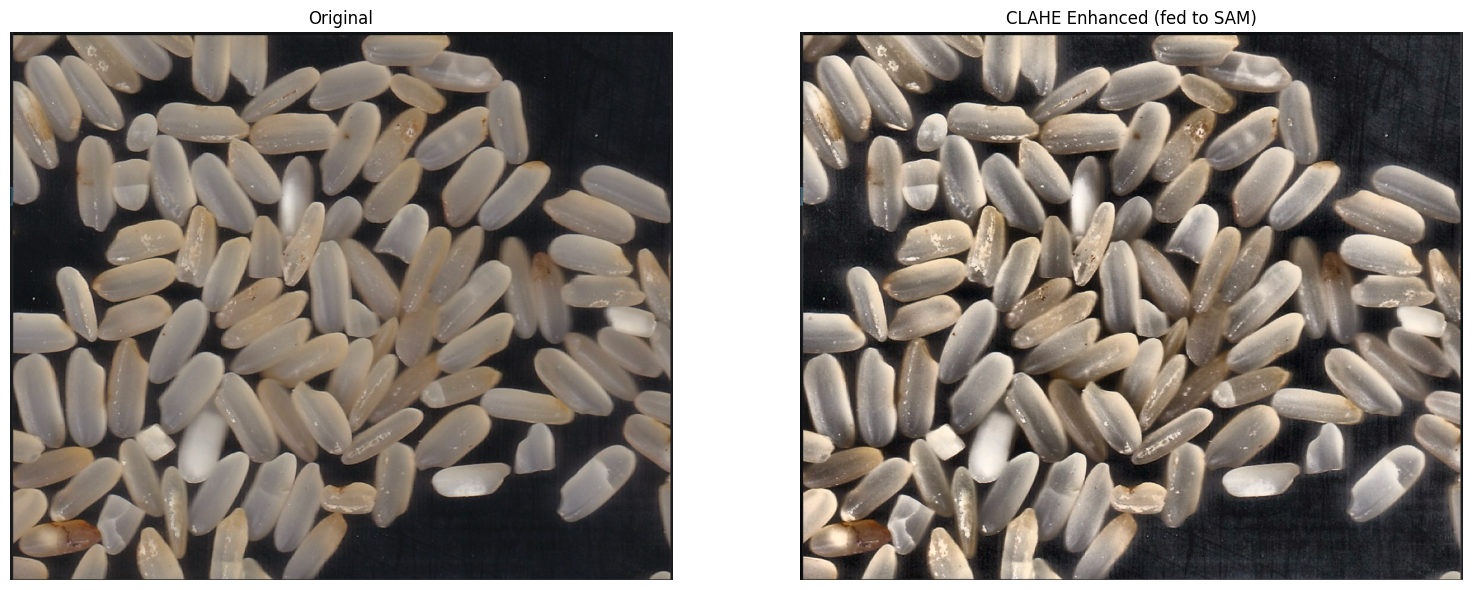

In [3]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Upload your rice grain image (JPG or PNG):")
uploaded = files.upload()
input_filename = list(uploaded.keys())[0]
print(f"Loaded: {input_filename}")

image_bgr = cv2.imread(input_filename)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
H, W = image_rgb.shape[:2]
print(f"Image shape: {H} x {W}")

# ── CLAHE pre-processing ─────────────────────────────────────────────────────
# Operate in LAB color space so only luminance is equalized
lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
lab[:, :, 0] = clahe.apply(lab[:, :, 0])
enhanced_bgr = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
enhanced_rgb = cv2.cvtColor(enhanced_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(image_rgb);  axes[0].set_title("Original");  axes[0].axis("off")
axes[1].imshow(enhanced_rgb); axes[1].set_title("CLAHE Enhanced (fed to SAM)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

## Step 4 — Load SAM & Configure Mask Generator

### Key parameter changes vs v1

| Parameter | v1 | v2 | Reason |
|---|---|---|---|
| `points_per_side` | 64 | **96** | Denser grid → fewer missed grains |
| `pred_iou_thresh` | 0.80 | **0.86** | Stricter — cuts spurious background masks |
| `stability_score_thresh` | 0.90 | **0.92** | Stricter stability |
| `box_nms_thresh` | default | **0.55** | Less aggressive NMS → preserves overlapping grains |
| `crop_n_layers` | 1 | **2** | Two crop passes → better edge-grain recall |

In [4]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH)
sam.to(device=DEVICE)

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=96,              # denser grid
    pred_iou_thresh=0.86,            # stricter — fewer false positives
    stability_score_thresh=0.92,     # stricter stability
    box_nms_thresh=0.55,             # keep overlapping grains
    min_mask_region_area=300,        # ignore dust < 300 px²
    crop_n_layers=2,                 # two crop passes for edge grains
    crop_n_points_downscale_factor=2,
    points_per_batch=128,
)

print("SAM model loaded and mask generator configured.")

Device: cuda
SAM model loaded and mask generator configured.


## Step 5 — Run Inference

In [5]:
import time

print("Running SamAutomaticMaskGenerator on CLAHE-enhanced image...")
print("(~60–120 s on T4/A100 with vit_h/vit_l)")
t0 = time.time()

masks = mask_generator.generate(enhanced_rgb)   # use contrast-enhanced image

elapsed = time.time() - t0
print(f"Done in {elapsed:.1f} s  →  {len(masks)} raw masks")

# Print statistics
areas = [m['area'] for m in masks]
print(f"Area range: {min(areas)} – {max(areas)} px²")
print(f"Median area: {int(np.median(areas))} px²")

Running SamAutomaticMaskGenerator on CLAHE-enhanced image...
(~60–120 s on T4/A100 with vit_h/vit_l)
Done in 162.0 s  →  295 raw masks
Area range: 14 – 53925 px²
Median area: 3562 px²


## Step 6 — Filter Masks with Shape Constraints

**v2 adds shape-based filtering** beyond just area:

| Filter | What it removes |
|---|---|
| `area` bounds | Background blobs (too large) and dust (too small) |
| **Aspect ratio** | Perfectly square or near-circular masks (background corners, reflections) |
| **Solidity** | Highly irregular, non-convex blobs (not grain-shaped) |

Rice grains are elongated ellipses → aspect ratio typically 1.5–7, solidity > 0.75.

In [6]:
from scipy.ndimage import label as scipy_label

total_pixels = H * W

# ── Tunable thresholds ───────────────────────────────────────────────────────
MIN_AREA          = 300     # px² — dust/noise floor
MAX_AREA_FRACTION = 0.04    # ← tightened from 0.15 to 4% of image
MIN_ASPECT_RATIO  = 1.3     # grains are elongated (short/fat threshold)
MAX_ASPECT_RATIO  = 9.0     # reject impossibly thin slivers
MIN_SOLIDITY      = 0.72    # reject very irregular blobs
# ────────────────────────────────────────────────────────────────────────────

MAX_AREA = int(total_pixels * MAX_AREA_FRACTION)

def get_shape_features(seg_mask):
    """Return (aspect_ratio, solidity) for a binary mask."""
    contours, _ = cv2.findContours(
        seg_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    if not contours:
        return 1.0, 0.0
    cnt = max(contours, key=cv2.contourArea)
    # Aspect ratio from rotated bounding box
    if len(cnt) < 5:
        _, (w, h), _ = cv2.minAreaRect(cnt)
    else:
        _, (w, h), _ = cv2.fitEllipse(cnt) if len(cnt) >= 5 else cv2.minAreaRect(cnt)
    if min(w, h) == 0:
        return 1.0, 0.0
    aspect = max(w, h) / min(w, h)
    # Solidity = contour area / convex hull area
    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    cnt_area  = cv2.contourArea(cnt)
    solidity  = cnt_area / hull_area if hull_area > 0 else 0.0
    return aspect, solidity


filtered_masks = []
rejected_reasons = {"too_small": 0, "too_large": 0, "aspect": 0, "solidity": 0}

for m in masks:
    area = m["area"]
    if area < MIN_AREA:
        rejected_reasons["too_small"] += 1; continue
    if area > MAX_AREA:
        rejected_reasons["too_large"] += 1; continue
    aspect, solidity = get_shape_features(m["segmentation"])
    if not (MIN_ASPECT_RATIO <= aspect <= MAX_ASPECT_RATIO):
        rejected_reasons["aspect"] += 1; continue
    if solidity < MIN_SOLIDITY:
        rejected_reasons["solidity"] += 1; continue
    filtered_masks.append(m)

print(f"Raw masks       : {len(masks)}")
print(f"After filtering : {len(filtered_masks)}")
print(f"Rejected        : {rejected_reasons}")

Raw masks       : 295
After filtering : 208
Rejected        : {'too_small': 47, 'too_large': 1, 'aspect': 21, 'solidity': 18}


## Step 7 — Smooth Mask Boundaries

**v2 boundary smoothing pipeline per mask:**
1. `cv2.morphologyEx` with `MORPH_CLOSE` — fills small holes and gaps inside the grain
2. Gaussian blur on the float mask → creates soft alpha edge
3. Re-threshold at 0.5 → clean smooth binary boundary

This removes the jagged staircase edges from v1 and produces soft, rounded grain outlines matching the reference output.

In [7]:
def smooth_mask(seg: np.ndarray, close_ksize: int = 7, blur_ksize: int = 11) -> np.ndarray:
    """
    Smooth a binary segmentation mask.

    Args:
        seg        : bool (H, W) mask from SAM
        close_ksize: kernel size for morphological closing (fills holes)
        blur_ksize : Gaussian blur kernel (must be odd); larger = smoother edges

    Returns:
        Smoothed bool (H, W) mask.
    """
    # Step 1: morphological closing — connect broken grain edges & fill internal holes
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (close_ksize, close_ksize)
    )
    closed = cv2.morphologyEx(
        seg.astype(np.uint8), cv2.MORPH_CLOSE, kernel, iterations=2
    )

    # Step 2: Gaussian blur to soften the boundary (creates anti-aliased edge)
    blurred = cv2.GaussianBlur(
        closed.astype(np.float32),
        (blur_ksize, blur_ksize),
        sigmaX=0   # auto sigma based on ksize
    )

    # Step 3: re-threshold at midpoint → clean smooth mask
    smoothed = blurred >= 0.5
    return smoothed


# Apply smoothing to all filtered masks
print("Smoothing mask boundaries...")
for m in filtered_masks:
    m["segmentation"] = smooth_mask(
        m["segmentation"],
        close_ksize=7,   # increase to 9/11 for thicker grains
        blur_ksize=11    # increase for softer edges
    )

print(f"Done — {len(filtered_masks)} masks smoothed.")

Smoothing mask boundaries...
Done — 208 masks smoothed.


## Step 8 — Colorize & Build Output Canvas

In [8]:
def generate_distinct_colors(n: int, seed: int = 42) -> np.ndarray:
    """
    Generate n visually distinct, saturated RGB colors using evenly-spaced
    hues in HSV space with forced high saturation and brightness.
    Shuffled so spatially adjacent grains contrast strongly.
    """
    rng = np.random.default_rng(seed)
    colors = []
    for i in range(n):
        hue = (i / n + rng.uniform(-0.015, 0.015)) % 1.0
        sat = rng.uniform(0.75, 1.0)
        val = rng.uniform(0.80, 1.0)
        h6 = hue * 6
        ih = int(h6)
        f  = h6 - ih
        p, q, t = val*(1-sat), val*(1-sat*f), val*(1-sat*(1-f))
        rgb = [(val,t,p),(q,val,p),(p,val,t),(p,q,val),(t,p,val),(val,p,q)][ih % 6]
        colors.append([int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255)])
    rng.shuffle(colors)
    return np.array(colors, dtype=np.uint8)


# Paint: largest masks first, smallest last (smaller grains on top)
ordered = sorted(filtered_masks, key=lambda m: m["area"], reverse=True)
colors  = generate_distinct_colors(len(ordered))

canvas = np.zeros((H, W, 3), dtype=np.uint8)   # black background

for idx, mask_data in enumerate(ordered):
    canvas[mask_data["segmentation"]] = colors[idx % len(colors)]

print(f"Canvas built — {len(ordered)} grains painted.")

Canvas built — 208 grains painted.


## Step 9 — Visualize

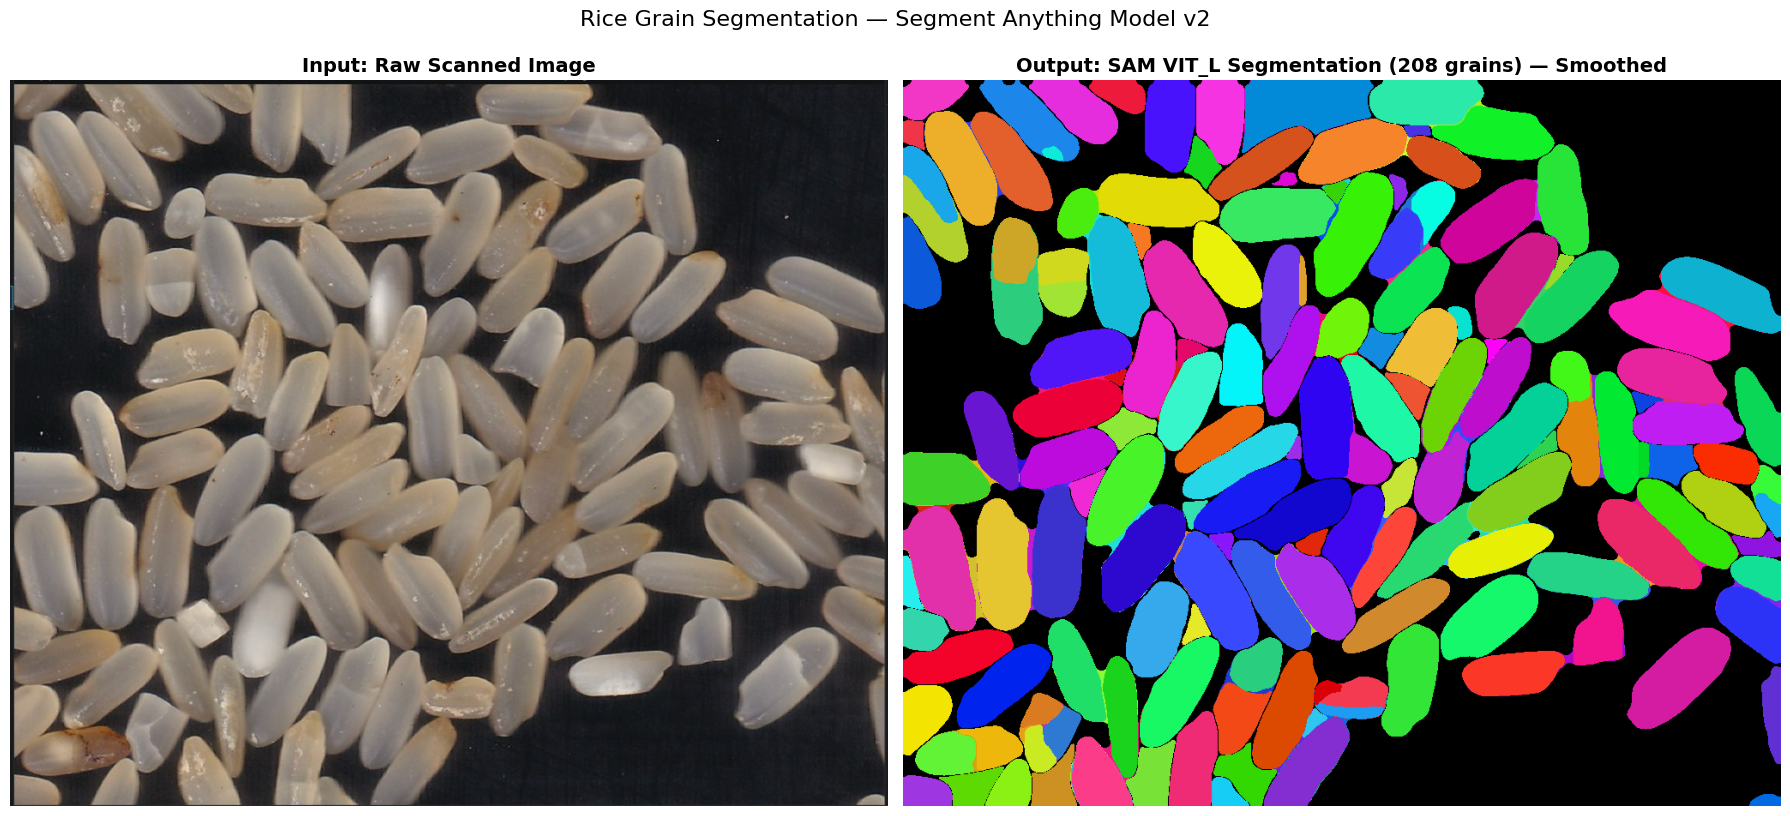

Saved: comparison_v2.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(image_rgb)
axes[0].set_title("Input: Raw Scanned Image", fontsize=14, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(canvas)
axes[1].set_title(
    f"Output: SAM {MODEL_TYPE.upper()} Segmentation ({len(ordered)} grains) — Smoothed",
    fontsize=14, fontweight="bold"
)
axes[1].axis("off")

plt.suptitle(
    "Rice Grain Segmentation — Segment Anything Model v2",
    fontsize=16, y=1.02
)
plt.tight_layout()
plt.savefig("comparison_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: comparison_v2.png")

## Step 10 — Save & Download

In [10]:
from PIL import Image

output_path = "segmented_rice_SAM_v2.png"
Image.fromarray(canvas).save(output_path)
print(f"Saved: {output_path}")

files.download(output_path)
files.download("comparison_v2.png")

Saved: segmented_rice_SAM_v2.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 11 — Quick Re-tune Cell

Re-run **only** this cell (+ Step 8–10) after tweaking — no need to re-run SAM inference.

| Symptom | Fix |
|---|---|
| Background still colored | Lower `MAX_AREA_FRACTION` to 0.02 |
| Grains look melted/fat | Lower `close_ksize` to 3 or 5 |
| Edges still jagged | Increase `blur_ksize` to 15 |
| Too many grains merged | Lower `box_nms_thresh` to 0.4 in Step 4 |
| Grains missed at edges | Increase `crop_n_layers` to 3 in Step 4 |
| Very elongated grains rejected | Increase `MAX_ASPECT_RATIO` to 12 |

Re-tuned: 202 grains


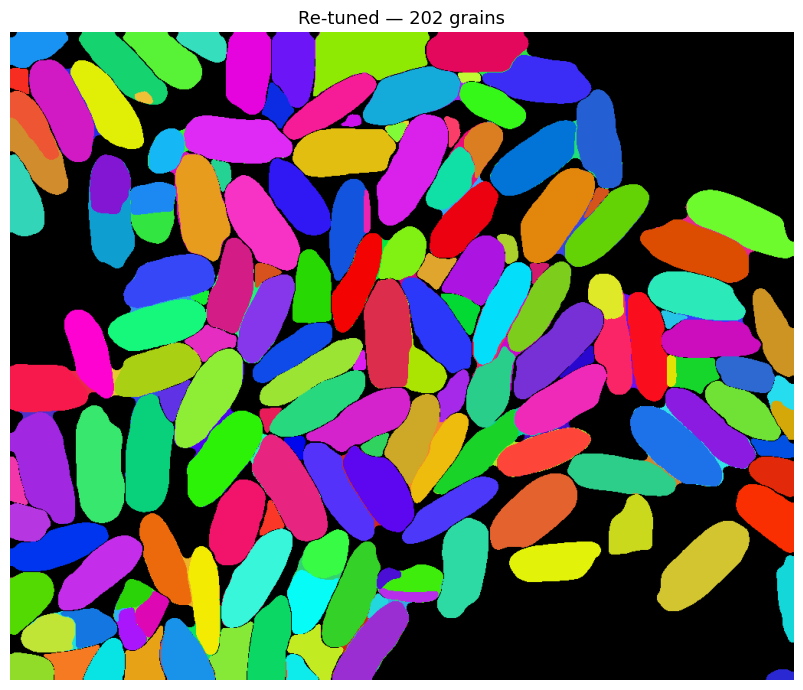

In [11]:
# ── Retune without re-running SAM ─────────────────────────────────────────

MIN_AREA          = 300
MAX_AREA_FRACTION = 0.04
MIN_ASPECT_RATIO  = 1.3
MAX_ASPECT_RATIO  = 9.0
MIN_SOLIDITY      = 0.72
CLOSE_KSIZE       = 7
BLUR_KSIZE        = 11

# Re-filter
MAX_AREA = int(total_pixels * MAX_AREA_FRACTION)
refiltered = []
for m in masks:
    if not (MIN_AREA <= m["area"] <= MAX_AREA): continue
    ar, sol = get_shape_features(m["segmentation"])
    if not (MIN_ASPECT_RATIO <= ar <= MAX_ASPECT_RATIO): continue
    if sol < MIN_SOLIDITY: continue
    refiltered.append(m)

# Re-smooth
for m in refiltered:
    m["segmentation"] = smooth_mask(m["segmentation"], CLOSE_KSIZE, BLUR_KSIZE)

# Re-paint
ordered2 = sorted(refiltered, key=lambda m: m["area"], reverse=True)
colors2  = generate_distinct_colors(len(ordered2))
canvas2  = np.zeros((H, W, 3), dtype=np.uint8)
for idx, md in enumerate(ordered2):
    canvas2[md["segmentation"]] = colors2[idx % len(colors2)]

print(f"Re-tuned: {len(ordered2)} grains")
plt.figure(figsize=(9, 7))
plt.imshow(canvas2)
plt.title(f"Re-tuned — {len(ordered2)} grains", fontsize=13)
plt.axis("off"); plt.tight_layout(); plt.show()

---

## Step 12 — Segment Any New Image

Run this single cell at any time after the notebook has been set up (Steps 1–4 must have run at least once so the model is loaded).

- Upload **any** rice grain image when prompted
- All pre-processing (CLAHE), SAM inference, filtering, smoothing, and colorisation happen automatically
- Only the **input vs output** side-by-side is shown — no intermediate steps
- Both the segmented PNG and the comparison PNG are downloaded automatically

Upload a rice grain image (JPG or PNG):


Saving 360_F_242388527_uDWUQEtsVjC5QYLHkCGeq4UR7mwYDSuy.jpg to 360_F_242388527_uDWUQEtsVjC5QYLHkCGeq4UR7mwYDSuy.jpg
Loaded : 360_F_242388527_uDWUQEtsVjC5QYLHkCGeq4UR7mwYDSuy.jpg
Image  : 360 x 449 px  |  CLAHE applied
Running SAM... (this may take 30–90 s)
SAM done in 163.3s  →  84 raw masks
After filtering : 35 grain masks


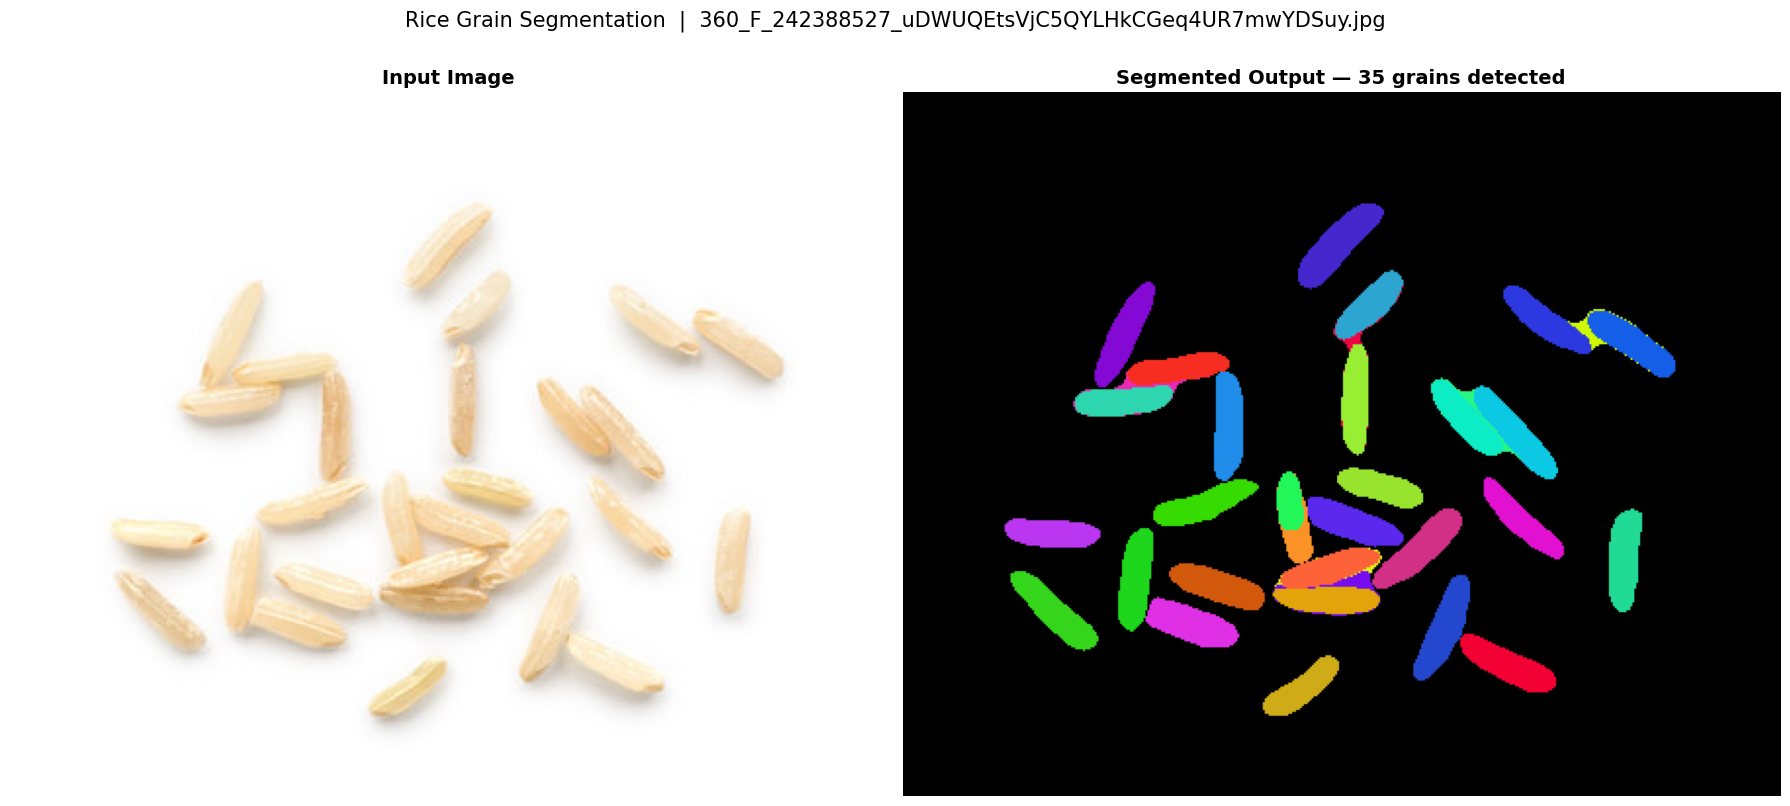

Saved  : segmented_new_360_F_242388527_uDWUQEtsVjC5QYLHkCGeq4UR7mwYDSuy.png  |  comparison_new_360_F_242388527_uDWUQEtsVjC5QYLHkCGeq4UR7mwYDSuy.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  SEGMENT A NEW IMAGE — run this cell standalone after initial setup     ║
# ║  Requires: Steps 1–4 already executed (model + helper fns in memory)   ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def segment_new_image(
    mask_gen,
    min_area: int   = 300,
    max_area_frac: float = 0.04,
    min_aspect: float    = 1.3,
    max_aspect: float    = 9.0,
    min_solidity: float  = 0.72,
    close_ksize: int     = 7,
    blur_ksize: int      = 11,
    color_seed: int      = 42,
) -> None:
    """
    Upload any rice grain image, run the full segmentation pipeline
    (CLAHE → SAM → filter → smooth → colorise), and display only the
    input/output comparison. Saves and downloads two files:
        segmented_new_<filename>.png   — segmented canvas only
        comparison_new_<filename>.png  — side-by-side comparison

    Parameters (all optional — defaults match the main notebook):
        mask_gen      : the SamAutomaticMaskGenerator already loaded in Step 4
        min_area      : minimum mask area in px² (removes dust/noise)
        max_area_frac : maximum mask area as fraction of image (removes background)
        min_aspect    : minimum aspect ratio (rejects square/circular blobs)
        max_aspect    : maximum aspect ratio (rejects impossibly thin slivers)
        min_solidity  : minimum solidity (rejects irregular non-grain shapes)
        close_ksize   : morphological closing kernel size for smoothing
        blur_ksize    : Gaussian blur kernel size for soft edges
        color_seed    : random seed — change for a different colour palette
    """
    import os
    import time
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt
    from PIL import Image
    from google.colab import files

    # ── 1. Upload ──────────────────────────────────────────────────────────
    print("Upload a rice grain image (JPG or PNG):")
    uploaded = files.upload()
    if not uploaded:
        print("No file uploaded. Aborting.")
        return
    fname = list(uploaded.keys())[0]
    stem  = os.path.splitext(fname)[0]          # filename without extension
    print(f"Loaded : {fname}")

    # ── 2. Read & CLAHE pre-process ────────────────────────────────────────
    img_bgr = cv2.imread(fname)
    if img_bgr is None:
        print(f"Could not read '{fname}'. Make sure it is a valid image file.")
        return
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w    = img_rgb.shape[:2]

    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    clahe_op = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe_op.apply(lab[:, :, 0])
    enhanced_rgb = cv2.cvtColor(
        cv2.cvtColor(lab, cv2.COLOR_LAB2BGR), cv2.COLOR_BGR2RGB
    )
    print(f"Image  : {h} x {w} px  |  CLAHE applied")

    # ── 3. SAM inference ──────────────────────────────────────────────────
    print("Running SAM... (this may take 30–90 s)")
    t0    = time.time()
    masks = mask_gen.generate(enhanced_rgb)
    print(f"SAM done in {time.time()-t0:.1f}s  →  {len(masks)} raw masks")

    # ── 4. Filter by area + shape ─────────────────────────────────────────
    max_area = int(h * w * max_area_frac)

    def _shape(seg):
        """Return (aspect_ratio, solidity) — reuses get_shape_features logic."""
        cnts, _ = cv2.findContours(
            seg.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        if not cnts:
            return 1.0, 0.0
        cnt = max(cnts, key=cv2.contourArea)
        if len(cnt) >= 5:
            _, (ew, eh), _ = cv2.fitEllipse(cnt)
        else:
            _, (ew, eh), _ = cv2.minAreaRect(cnt)
        if min(ew, eh) == 0:
            return 1.0, 0.0
        aspect   = max(ew, eh) / min(ew, eh)
        hull_a   = cv2.contourArea(cv2.convexHull(cnt))
        solidity = cv2.contourArea(cnt) / hull_a if hull_a > 0 else 0.0
        return aspect, solidity

    kept = []
    for m in masks:
        a = m["area"]
        if not (min_area <= a <= max_area):
            continue
        ar, sol = _shape(m["segmentation"])
        if not (min_aspect <= ar <= max_aspect):
            continue
        if sol < min_solidity:
            continue
        kept.append(m)
    print(f"After filtering : {len(kept)} grain masks")

    # ── 5. Smooth boundaries ──────────────────────────────────────────────
    def _smooth(seg, ck, bk):
        """Morphological closing + Gaussian blur — same as smooth_mask()."""
        kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ck, ck))
        closed  = cv2.morphologyEx(
            seg.astype(np.uint8), cv2.MORPH_CLOSE, kernel, iterations=2
        )
        blurred = cv2.GaussianBlur(closed.astype(np.float32), (bk, bk), 0)
        return blurred >= 0.5

    for m in kept:
        m["segmentation"] = _smooth(m["segmentation"], close_ksize, blur_ksize)

    # ── 6. Colorise ───────────────────────────────────────────────────────
    def _colors(n, seed):
        """Evenly-spaced HSV hues, high saturation, shuffled."""
        rng = np.random.default_rng(seed)
        out = []
        for i in range(n):
            hue = (i / n + rng.uniform(-0.015, 0.015)) % 1.0
            sat = rng.uniform(0.75, 1.0)
            val = rng.uniform(0.80, 1.0)
            h6  = hue * 6; ih = int(h6); f = h6 - ih
            p, q, t = val*(1-sat), val*(1-sat*f), val*(1-sat*(1-f))
            r, g, b = [(val,t,p),(q,val,p),(p,val,t),
                       (p,q,val),(t,p,val),(val,p,q)][ih % 6]
            out.append([int(r*255), int(g*255), int(b*255)])
        rng.shuffle(out)
        return np.array(out, dtype=np.uint8)

    ordered = sorted(kept, key=lambda m: m["area"], reverse=True)
    palette = _colors(len(ordered), color_seed)
    canvas  = np.zeros((h, w, 3), dtype=np.uint8)          # black background
    for idx, md in enumerate(ordered):
        canvas[md["segmentation"]] = palette[idx % len(palette)]

    # ── 7. Show input vs output only (no intermediate steps) ─────────────
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    axes[0].imshow(img_rgb)
    axes[0].set_title("Input Image", fontsize=14, fontweight="bold")
    axes[0].axis("off")
    axes[1].imshow(canvas)
    axes[1].set_title(
        f"Segmented Output — {len(ordered)} grains detected",
        fontsize=14, fontweight="bold"
    )
    axes[1].axis("off")
    plt.suptitle(
        f"Rice Grain Segmentation  |  {fname}",
        fontsize=15, y=1.02
    )
    plt.tight_layout()

    cmp_path = f"comparison_new_{stem}.png"
    plt.savefig(cmp_path, dpi=150, bbox_inches="tight")
    plt.show()

    # ── 8. Save & download ────────────────────────────────────────────────
    seg_path = f"segmented_new_{stem}.png"
    Image.fromarray(canvas).save(seg_path)
    print(f"Saved  : {seg_path}  |  {cmp_path}")
    files.download(seg_path)
    files.download(cmp_path)


# ── Run it ────────────────────────────────────────────────────────────────
# Uses the mask_generator already loaded in Step 4.
# All parameters are optional — defaults match the main pipeline exactly.
segment_new_image(mask_generator)

---

## Approach & Changes Summary

### Model Upgrade
ViT-H (2.4 GB) replaces ViT-B. The larger image encoder produces significantly more accurate mask boundaries, especially for overlapping and partially occluded grains. Auto-fallback to ViT-L on GPUs with < 16 GB VRAM ensures the notebook runs on free Colab T4s too.

### Fix 1 — Background blob eliminated
The large green blob in v1 was a single SAM mask covering the empty dark background region (top-right). It passed the loose `MAX_AREA_FRACTION=0.15` threshold. Two fixes compound:
- `MAX_AREA_FRACTION` reduced to **0.04** — a rice grain occupies at most ~3% of this image.
- **Shape filtering**: background regions have low aspect ratio (square-ish) or low solidity (irregular). Rice grains are elongated ellipses (aspect ratio 1.5–7, solidity > 0.72). Any mask that doesn't match grain geometry is discarded.

### Fix 2 — Boundary smoothing
SAM returns pixel-perfect binary masks whose edges follow the actual raster grid, producing a staircase/jagged appearance. The smoothing pipeline applies:
1. **Morphological closing** (elliptical 7×7 kernel, 2 iterations) — bridges small gaps between pixels and fills holes inside grains.
2. **Gaussian blur** (11×11) on the float mask — diffuses the hard boundary into a soft gradient.
3. **Re-threshold at 0.5** — snaps back to a binary mask with the now-smooth boundary.

### Fix 3 — CLAHE pre-processing
The raw image has low contrast between bright grains and the dark background in shadow areas. CLAHE (applied to the L channel in LAB space) enhances local contrast without washing out highlights, giving SAM cleaner grain boundaries to work with.

### Potential further improvements
- **SAM 2** (released Aug 2024) has a more powerful image encoder and better boundary precision — a drop-in improvement.
- **Prompt-mode SAM**: detect grain centroids with a classical blob detector (Laplacian of Gaussian), feed them as positive point prompts — gives more control over per-grain masks.
- **Watershed post-processing** on the SAM canvas to split any remaining merged grains.